# Amazon Food Reviews Sentiment Analysis using NLP

This project focuses on analyzing customer reviews from Amazon food products and predicting the sentiment of each review using Natural Language Processing (NLP) techniques.

The objective of this project is to classify reviews into:

- Positive Reviews
- Neutral Reviews
- Negative Reviews

We use Machine Learning models along with NLP preprocessing techniques such as:

- Text Cleaning
- Tokenization
- Stopword Removal
- TF-IDF Vectorization

Finally, we train a classification model to predict customer sentiment.

## Import Required Libraries

In this step we import all required Python libraries for:

- Data manipulation
- Visualization
- NLP preprocessing
- Machine learning

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.corpus import stopwords

Explanation:

Pandas → Used for handling dataset  
NumPy → Numerical computations  
Matplotlib & Seaborn → Data visualization  
NLTK → Natural Language Processing tasks  
Regex → Cleaning text data  

Scikit-learn is used for:

Train Test Split → dividing dataset  
TF-IDF Vectorizer → converting text into numbers  
Logistic Regression → classification model  
Evaluation Metrics → measuring model performance

## Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Chinnarajan M\OneDrive\Desktop\Imarticus Learning-PGA\Python\Neural Networks\RNN\AmazonFoodReviews.csv")

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


We load the Amazon Food Reviews dataset using pandas.

Important columns include:

Score → rating given by the user  
Summary → short review title  
Text → full customer review

We mainly use the **Text column** for sentiment analysis.

In [3]:
df.shape

(568454, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [5]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

Dataset contains more than **500,000 reviews**.

We check:

Number of rows and columns  
Data types of each column  
Missing values

For this project we mainly focus on:

Text → review content  
Score → sentiment label

Since the missing values are very few, the best practice is to remove them

In [9]:
df = df.dropna(subset=['ProfileName','Summary'])

dropna() removes rows with missing values.

subset ensures only rows with null in ProfileName or Summary are removed.

This will remove only about 53 rows, which will not affect the dataset.

In [10]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

No missing values remain, so we can safely proceed with the NLP preprocessing and model building

## Convert Score into Sentiment Labels

In [11]:
def sentiment_label(score):
    
    if score <= 2:
        return "Negative"
    
    elif score == 3:
        return "Neutral"
    
    else:
        return "Positive"


df["Sentiment"] = df["Score"].apply(sentiment_label)

df["Sentiment"].value_counts()

Sentiment
Positive    443756
Negative     82007
Neutral      42638
Name: count, dtype: int64

Amazon ratings range from **1 to 5**.

We convert them into sentiment categories:

1–2 → Negative  
3 → Neutral  
4–5 → Positive

This transformation allows us to build a **classification model**.

## Text Preprocessing

Raw text contains noise such as:

- punctuation
- special characters
- stopwords

We clean the text before training the model.

In [12]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)


df["Clean_Text"] = df["Text"].apply(clean_text)

df.head()

[nltk_data] Downloading package stopwords to C:\Users\Chinnarajan
[nltk_data]     M\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,Sentiment,Clean_Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive,bought several vitality canned dog food produc...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative,product arrived labeled jumbo salted peanuts p...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,Positive,confection around centuries light pillowy citr...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,Negative,looking secret ingredient robitussin believe f...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,Positive,great taffy great price wide assortment yummy ...


Steps in text preprocessing:

Lowercasing → convert all text to lowercase  
Regex cleaning → remove numbers and punctuation  
Tokenization → split text into words  
Stopword removal → remove common words like "the", "is", "and"

The cleaned text is stored in **Clean_Text column**.

## TF-IDF Vectorization

In [13]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["Clean_Text"])

Y = df["Sentiment"]

Machine learning models cannot understand text.

TF-IDF converts text into **numerical vectors**.

TF → term frequency  
IDF → inverse document frequency

This technique highlights important words in the dataset.

In [14]:
# Train Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

We split the dataset into:

Training Data → 80%  
Testing Data → 20%

Training data is used to train the model.  
Testing data is used to evaluate model performance.

## Model Training

In [15]:
model = LogisticRegression()

model.fit(X_train, Y_train)

C:\Users\Chinnarajan M\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

We use **Logistic Regression** for text classification.

It works well for:

Sentiment analysis  
Spam detection  
Document classification

In [16]:
# Model Prediction
Y_pred = model.predict(X_test)

In [17]:
# Model Evaluation
print("Accuracy:", accuracy_score(Y_test, Y_pred))

print(classification_report(Y_test, Y_pred))

Accuracy: 0.8674624607454192
              precision    recall  f1-score   support

    Negative       0.74      0.67      0.71     16452
     Neutral       0.52      0.18      0.27      8460
    Positive       0.90      0.97      0.93     88769

    accuracy                           0.87    113681
   macro avg       0.72      0.61      0.64    113681
weighted avg       0.85      0.87      0.85    113681



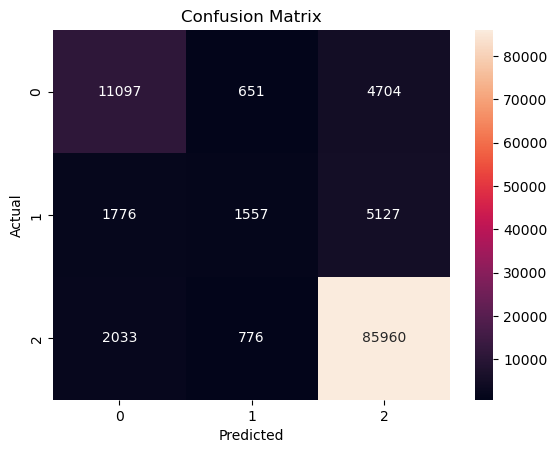

In [18]:
cm = confusion_matrix(Y_test, Y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Correct Predictions (Diagonal Values)

The diagonal elements represent the number of correct predictions made by the model.

11,097 negative reviews were correctly predicted as negative.

1,557 neutral reviews were correctly predicted as neutral.

85,960 positive reviews were correctly predicted as positive.

This indicates that the model performs very well in identifying positive reviews, which dominate the dataset.

# Misclassifications

The off-diagonal elements represent incorrect predictions.

# Negative Reviews

651 negative reviews were predicted as neutral.

4,704 negative reviews were predicted as positive.

This means some negative reviews contain words that the model interprets as positive.

# Neutral Reviews

1,776 neutral reviews were predicted as negative.

5,127 neutral reviews were predicted as positive.

Neutral reviews are the most difficult for the model to classify because they often contain mixed sentiments.

# Positive Reviews

2,033 positive reviews were predicted as negative.

776 positive reviews were predicted as neutral.

However, compared to the large number of positive reviews, these errors are relatively small.

# Key Insights from the Graph

The confusion matrix compares actual and predicted sentiment classes. The model performs very well for positive reviews but struggles slightly with neutral reviews due to mixed sentiment language.

## Conclusion

In this project we built an NLP based sentiment analysis system for Amazon food reviews.

Key steps in the project:

Data preprocessing  
Text cleaning  
TF-IDF feature extraction  
Machine learning model training  

The Logistic Regression model successfully classified reviews into positive, neutral, and negative sentiments.

This type of system can help companies:

Understand customer opinions  
Improve product quality  
Monitor customer satisfaction